## **Brief Description About the The Medical Insurance Dataset:**

The Medical Insurance dataset contains records of individuals' demographic, health, and lifestyle information, along with their insurance charges.

The goal is to predict insurance charges (charges) based on factors like age, sex, BMI, children, smoker, and region. 

This dataset has 1,137 rows and 7 columns.

Columns include:

- age: Age of the individual.
- sex: Gender of the individual.
- bmi: Body Mass Index (BMI).
- children: Number of children covered by the insurance.
- smoker: Whether the individual is a smoker.
- region: The individual's residential region.
- charges: The medical insurance charges (target variable).

## **Step 1: Data Exploration**

1- Import essential libraries 

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2- reading the dataset form insurance_dataset.csv

In [7]:
data = pd.read_csv('insurance_dataset.csv')

3- Display head and tail of the data set

In [11]:
print(data.head())
print(data.tail())

   age     sex     bmi  children smoker     region      charges
0   52    male  27.360         0    yes  northwest  24393.62240
1   30    male  44.220         2     no  southeast   4266.16580
2   19    male  27.265         2     no  northwest  22493.65964
3   20  female  26.840         1    yes  southeast  17085.26760
4   27  female  24.750         0    yes  southeast  16577.77950
      age     sex     bmi  children smoker     region      charges
1132   18  female  31.350         4     no  northeast   4561.18850
1133   39  female  23.870         5     no  southeast   8582.30230
1134   58    male  25.175         0     no  northeast  11931.12525
1135   37  female  47.600         2    yes  southwest  46113.51100
1136   55    male  29.900         0     no  southwest  10214.63600


4- Display all coloums' names

In [14]:
print('The columns are: ', data.columns)

The columns are:  Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


5- Display the number of rows in the data set

In [17]:
print('Number of rows: ', data.shape[0])

Number of rows:  1137


6- use **.describe() method** to generate descriptive statistics and summarize the dataset

In [20]:
data.describe()

,age,bmi,children,charges
count,1137.000000,1137.000000,1137.000000,1137.000000
mean,35.681618,30.550752,0.985928,13285.245207
std,21.581298,6.124758,1.305384,12068.858512
min,-63.000000,15.960000,-5.000000,1121.873900
25%,25.000000,26.180000,0.000000,4779.602300
50%,38.000000,30.210000,1.000000,9504.310300
75%,51.000000,34.485000,2.000000,16586.497710
max,64.000000,53.130000,5.000000,63770.428010


7- Use **.info() method** to display the number of non-empty cells in each column.

If the column has no empty value, the total count should equal the number of records in the dataset.

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137 entries, 0 to 1136
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1137 non-null   int64  
 1   sex       1137 non-null   object 
 2   bmi       1137 non-null   float64
 3   children  1137 non-null   int64  
 4   smoker    1137 non-null   object 
 5   region    1080 non-null   object 
 6   charges   1137 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 62.3+ KB


- we can notice that all columns has the same number of rows except region column that has 57 missing values (null cells).

In [26]:
# Get the total number of rows in the dataset
total_rows_count = data.shape[0]

# use count() method to get the total non-empty cells of the tatal region
total_non_null_cells = data["region"].count()

# Calculate the total empty cells
null_cells_count = total_rows_count - total_non_null_cells

# Print the number of null cells.
print("The number of missing values in region column is:",null_cells_count)

The number of missing values in region column is: 57


## **Step 2: Data Visualization**

#### **First**, We will start with ploting the histograms of the numerical data features to see how they are distributed

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'children'}>,
        <Axes: title={'center': 'charges'}>]], dtype=object)

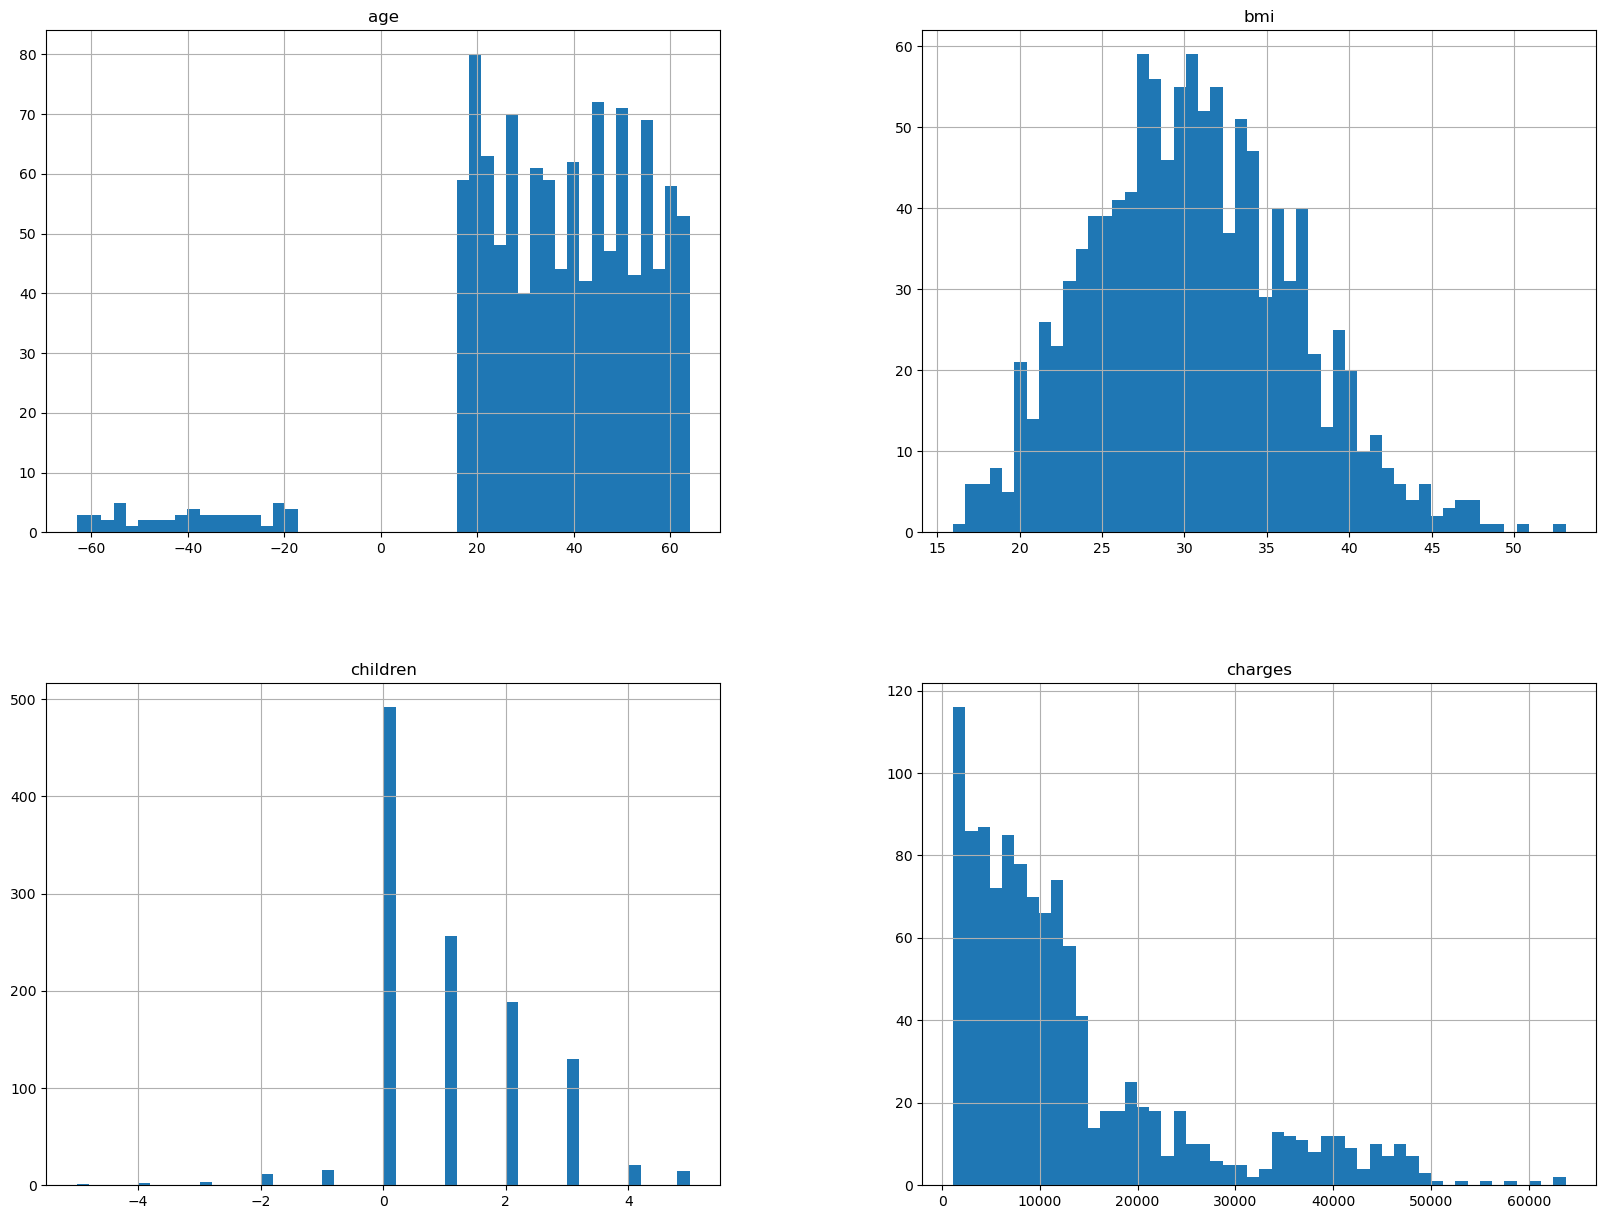

In [30]:
data.hist(bins=50, figsize=(20,15))

**1) Histogram for BMI**

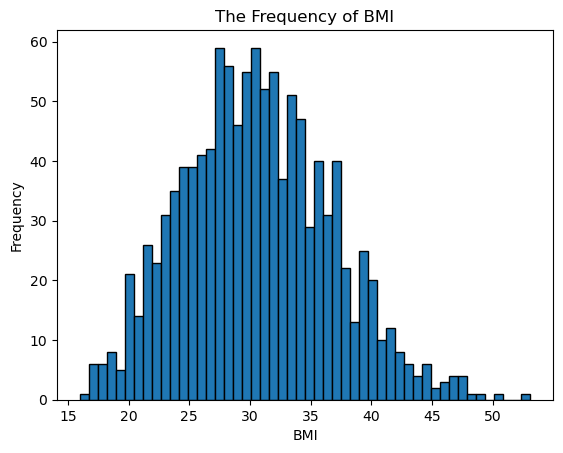

In [33]:
plt.hist(data['bmi'], bins=50, edgecolor='black')

plt.title("The Frequency of BMI")

plt.xlabel("BMI")
plt.ylabel("Frequency")

# Display the output
plt.show()

**We can notice from the graph that:**
1) bmi is normally distributed with most values ranged approximately between 20 and 40.
   
2) Outliers are present on the higher end (above 50), but they are infrequent.

**2) Histogram for Age**

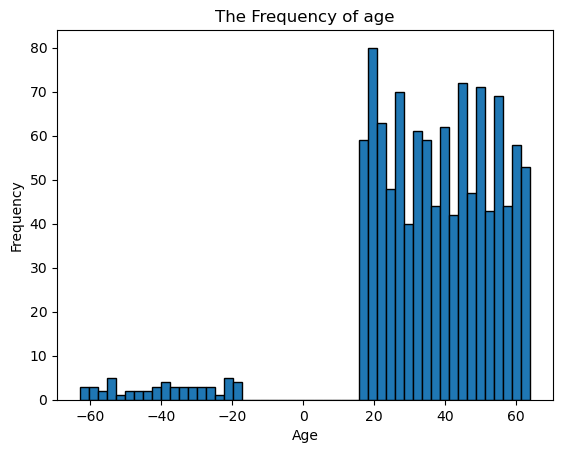

In [37]:
plt.hist(data['age'], bins=50, edgecolor='black')

plt.title("The Frequency of age")

plt.xlabel("Age")
plt.ylabel("Frequency")

# Display the output
plt.show()

**The histogram for the age shows that:**

1) The distribution of age is approximately uniform within the range of valid ages (between 18 and 65 years).

2) There are unexpected negative values on the x-axis (from -60 to -20), which may indicate errors in the data or incorrect data entry.

**3) Histogram of Charges**

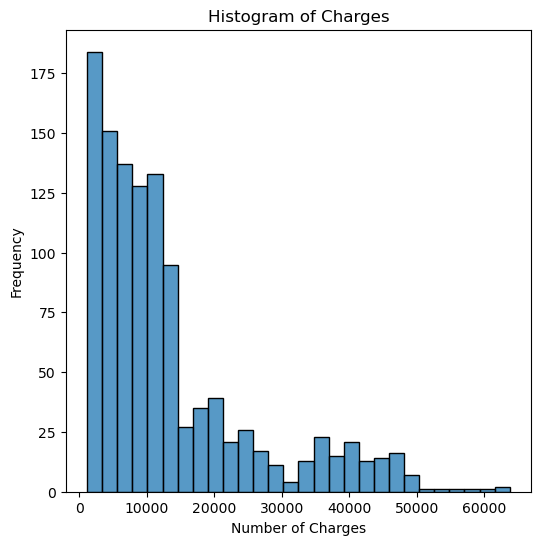

In [41]:
plt.figure(figsize=(6, 6))

sns.histplot(data['charges'])

plt.title('Histogram of Charges')
plt.xlabel('Number of Charges')
plt.ylabel('Frequency')

plt.show()

**Observations from charges Histogram graph:**

1- Skewed Distribution:
- The distribution of charges is positively skewed (right-skewed), meaning most individuals have lower healthcare charges, but there are a few with very high costs

2- High Frequency of Low Charges:

- A significant number of individuals have charges between $0 and $10,000, which is where the majority of data points are concentrated.

3-Long Tail:

- The tail of the distribution stretches towards higher values (up to $60,000+), indicating that while high charges are rare, they exist in the dataset representing outliers.

**4) Children Distribution**

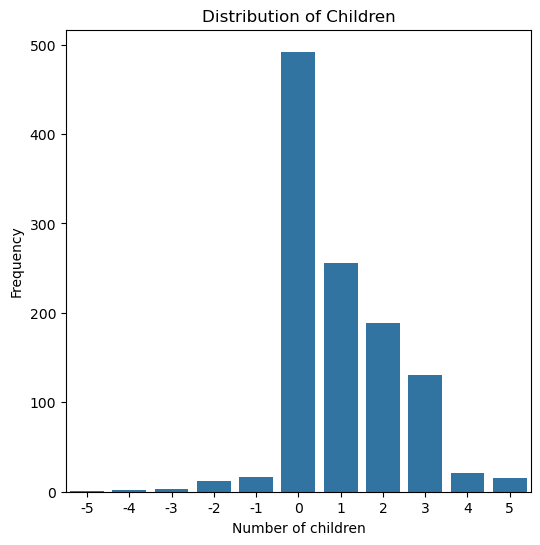

In [45]:
plt.figure(figsize=(6,6))
sns.countplot(x='children', data=data)

plt.title('Distribution of Children')
plt.xlabel('Number of children')
plt.ylabel('Frequency')

plt.show()

**The Distribution for number of children shows that:**

- Number of children ranges between 0 and 5

- The children histogram is heavily skewed to the right, with most individuals having 0 to 2 children.

- Negative values on the x-axis are likely invalid or indicative of data errors because the number of childern is a numerical dicrete datatype that can't be negative

#### **Second**, we will plot the Distribution for categorical features

**Sex Distribution**

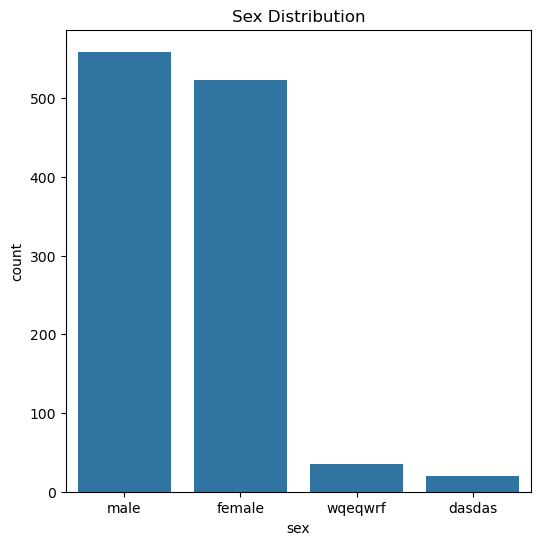

In [50]:
plt.figure(figsize=(6,6))
sns.countplot(x='sex', data=data)
plt.title('Sex Distribution')
plt.show()

- The sex feature has balanced classes between male and female but includes invalid categories (typos). 

**Smoking Distribution**

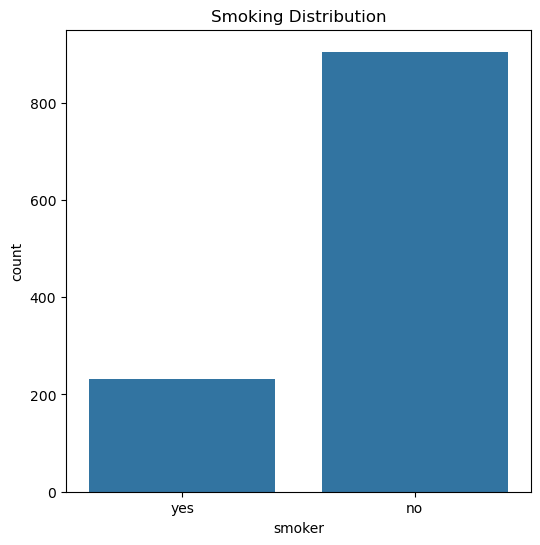

In [54]:
plt.figure(figsize=(6,6))
sns.countplot(x='smoker', data=data)
plt.title('Smoking Distribution')
plt.show()

- The data shows a significant imbalance between smokers and non-smokers because the number of non smokers is relatively higher that smokers.

**Is resample needed in this case?**

- no need to resample (smoker) as it is a feature variable, it will not affect the model training directly.
  
- If the class distribution of the target variable is highly imbalanced, the model may become biased towards the majority class. In this case, resampling is needed.

**Region Distribution**

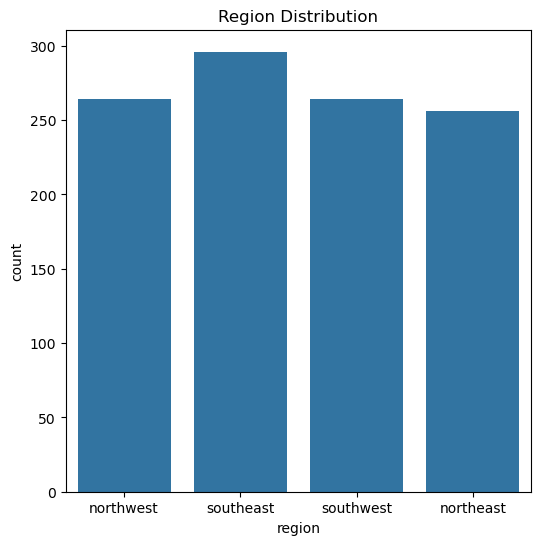

In [58]:
plt.figure(figsize=(6,6))
sns.countplot(x='region', data=data)
plt.title('Region Distribution')
plt.show()

- The regions are relatively balanced, with almost equal representaions of each class  

#### **Third**, we will display Boxplots to identify the outliers existing the dataset

**Children Boxplot**

<Axes: ylabel='children'>

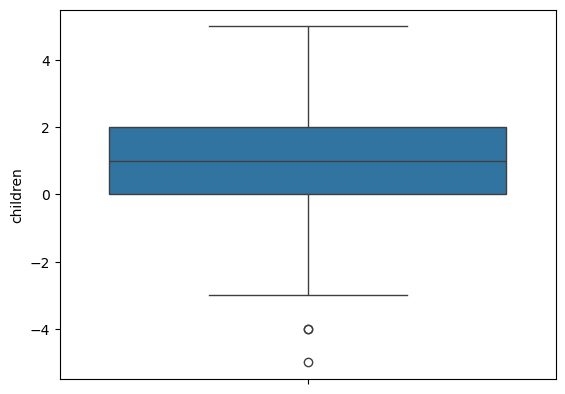

In [63]:
sns.boxplot(data['children'])

**The boxplot of children shows that:**

- There are outliers below 0 (negative values) which are impossible for this context.
  
- Any negative values need to be cleaned even if the box plot shows that they are not outliers, becaues it's impossible to have negative number of children. 

**Age Boxplot**

<Axes: ylabel='age'>

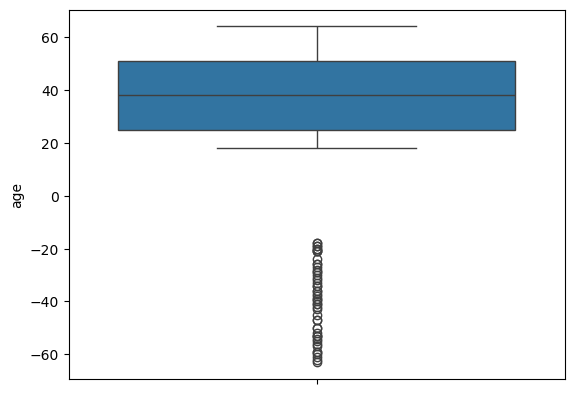

In [67]:
sns.boxplot(data['age'])

**The boxplot of age shows that:**

- There are outliers below 0 (negative values) which are impossible for this context (invalid values).

- The majority of ages fall between approximately 20 and 50

**BMI Boxplot**

<Axes: ylabel='bmi'>

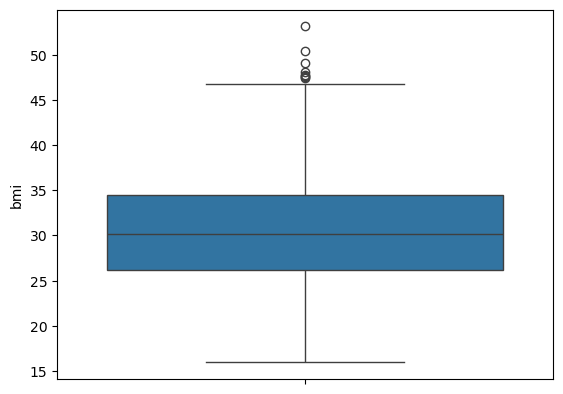

In [71]:
sns.boxplot(data['bmi'])

**The boxplot of BMI shows that:**
    
- There are few outliers above 47

- BMI is normally distributed and the majority fall between 25 and 35.

**Charges Boxplot**

<Axes: ylabel='charges'>

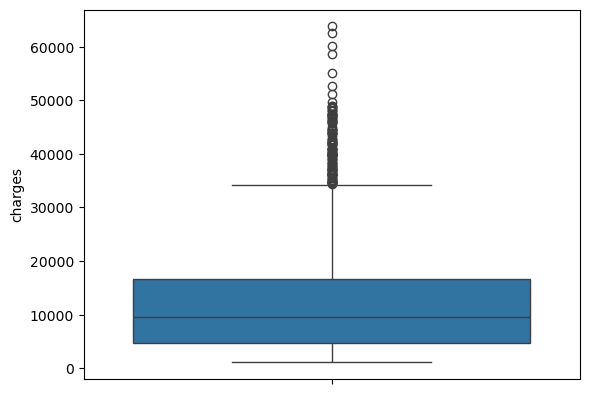

In [75]:
sns.boxplot(data['charges'])

**The boxplot of charges shows that:**

- The majority of charges values lie approximately between 5000 and 20000

- A significant number of outliers present in charges values.
  
- Charges distribution is positively skewed.

#### **The relation between BMI and charges**

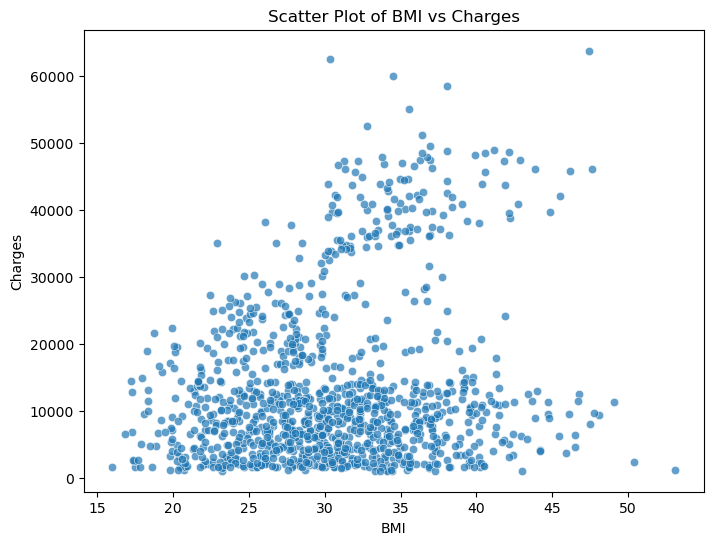

In [79]:
# Scatter plot of BMI vs charges
plt.figure(figsize=(8, 6))
sns.scatterplot(x='bmi', y='charges', data=data, alpha=0.7)
plt.title('Scatter Plot of BMI vs Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')

plt.show()

- The scatter plot shows a positive correlation between BMI and charges
  
- There seems to be a general upward trend in charges as BMI increases, especially for individuals with higher BMI values (closer to 30 or above). This indicates that people with higher BMI are associated with higher charges

#### **How smoking affects the total medical charges**

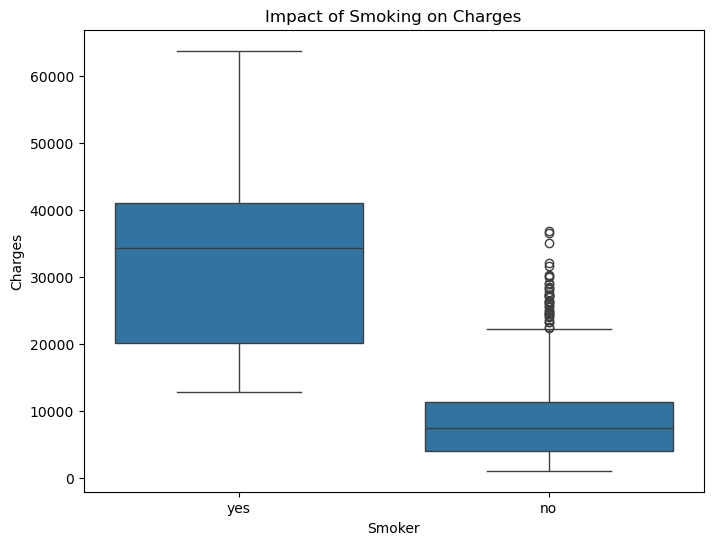

In [83]:
# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=data)
plt.title('Impact of Smoking on Charges')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

**This graph shows that smokers tend to have a much higher range of charges than non smokers.**
- The variability in charges for smokers is greater, suggesting that smoking is likely associated with higher healthcare costs.
- Non-smokers generally have lower medical costs, but the outliers might represent individuals with expensive health conditions unrelated to smoking.

#### **Covariance, Correlation and Heat Map**

**Now, lets find how these features are related to the target.**

1) we take a copy of the data not to change the original dataset
2) we remove all missing values in the region feature to ensure consistency and accuracy for all correlation calculations

In [88]:
data_copy = data.copy()
data_copy= data_copy.dropna(subset=['region'])

3) we encode categorical features because covariance and correlation can be done only on numerical features
  - one hot encodeing for region.
  - label incoding for sex and smoker.

In [91]:
from sklearn import preprocessing 
from sklearn.preprocessing import OneHotEncoder

# Initialize the OneHotEncoder
one_hot_encoder = OneHotEncoder(sparse_output=False)  # Keep all categories

# Perform one-hot encoding on the 'region' column
region_encoded = one_hot_encoder.fit_transform(data_copy[['region']])

# Convert the one-hot encoded array to a DataFrame
region_encoded_df = pd.DataFrame(region_encoded, columns=one_hot_encoder.get_feature_names_out(['region']))

# Drop the original 'region' column and concatenate the encoded DataFrame
data_copy = pd.concat([data_copy.drop('region', axis=1), region_encoded_df], axis=1)

# Encode other categorical columns with LabelEncoder
label_encoder = preprocessing.LabelEncoder()
data_copy['sex'] = label_encoder.fit_transform(data_copy['sex'])
data_copy['smoker'] = label_encoder.fit_transform(data_copy['smoker'])

**1- Covariance**

In [94]:
# Calculate the covariance matrix
data_copy.cov()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
age,465.117694,-0.292915,8.944253,0.762432,-0.554773,3.408501e+04,-0.103873,0.011850,0.050363,0.041660
sex,-0.292915,0.614519,0.117133,0.026139,0.228219,5.198048e+02,-0.006227,-0.012996,0.009048,0.010174
bmi,8.944253,0.117133,37.179487,0.166658,0.048104,1.533244e+04,0.050449,-0.027246,0.039017,-0.062220
children,0.762432,0.026139,0.166658,1.720728,0.007229,7.897332e+02,0.000099,-0.021114,0.017821,0.003194
smoker,-0.554773,0.228219,0.048104,0.007229,0.304225,3.782141e+03,-0.001277,-0.001606,0.002636,0.000247
charges,34085.007458,519.804845,15332.438979,789.733236,3782.141144,1.461685e+08,-115.067598,94.180018,179.347140,-158.459560
region_northeast,-0.103873,-0.006227,0.050449,0.000099,-0.001277,-1.150676e+02,0.181018,-0.057996,-0.065026,-0.057996
region_northwest,0.011850,-0.012996,-0.027246,-0.021114,-0.001606,9.418002e+01,-0.057996,0.184863,-0.067058,-0.059808
region_southeast,0.050363,0.009048,0.039017,0.017821,0.002636,1.793471e+02,-0.065026,-0.067058,0.199142,-0.067058
region_southwest,0.041660,0.010174,-0.062220,0.003194,0.000247,-1.584596e+02,-0.057996,-0.059808,-0.067058,0.184863


**2- Correlation**

In [97]:
data_copy.corr()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
age,1.000000,-0.023053,0.068016,0.026950,-0.064280,0.130724,-0.011212,0.001263,0.005207,0.004466
sex,-0.023053,1.000000,0.032606,0.033822,0.527820,0.072977,-0.018417,-0.038037,0.025516,0.029779
bmi,0.068016,0.032606,1.000000,0.020836,0.019714,0.207985,0.019411,-0.010355,0.014381,-0.023774
children,0.026950,0.033822,0.020836,1.000000,0.013771,0.049796,0.000178,-0.037422,0.030632,0.005692
smoker,-0.064280,0.527820,0.019714,0.013771,1.000000,0.781717,-0.005375,-0.006692,0.010580,0.001030
charges,0.130724,0.072977,0.207985,0.049796,0.781717,1.000000,-0.022382,0.018095,0.033418,-0.030609
region_northeast,-0.011212,-0.018417,0.019411,0.000178,-0.005375,-0.022382,1.000000,-0.317039,-0.342487,-0.317039
region_northwest,0.001263,-0.038037,-0.010355,-0.037422,-0.006692,0.018095,-0.317039,1.000000,-0.349498,-0.323529
region_southeast,0.005207,0.025516,0.014381,0.030632,0.010580,0.033418,-0.342487,-0.349498,1.000000,-0.349498
region_southwest,0.004466,0.029779,-0.023774,0.005692,0.001030,-0.030609,-0.317039,-0.323529,-0.349498,1.000000


**3-Heat Map**

<Axes: >

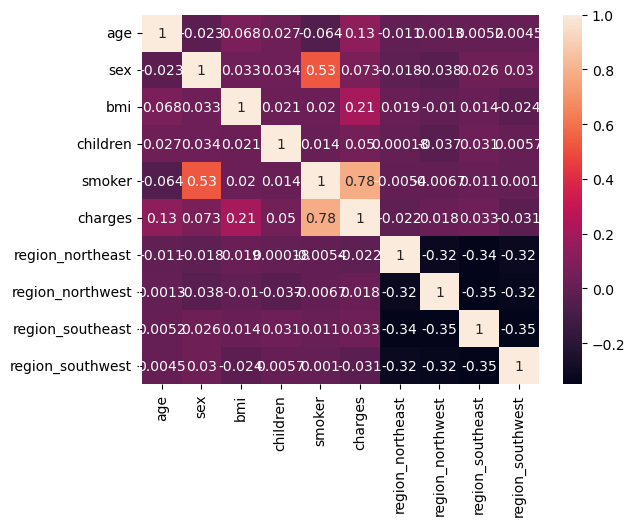

In [100]:
sns.heatmap(data_copy.corr(),annot=True)

**This heat map shows:**

**1- Strong Positive Correlation Between Smoker and Charges (0.78):**

- Smoking is strongly correlated with higher charges, suggesting that smokers tend to have significantly higher healthcare costs.

**2- Moderate Positive Correlation Between BMI and Charges (0.21):**

- Higher BMI values are moderately associated with increased charges, possibly indicating that obesity or related health issues contribute to higher healthcare costs.

**3- Weak Positive Correlation Between Age and Charges (0.13):**

- Older individuals tend to have slightly higher charges, which might reflect age-related health issues

**4- Very Weak Positive Correlation Between Sex and Charges (0.073):**

- this correlation suggest that the gender of the individual has little impact on insurance charges.

**5- Very Weak Positive Correlation Between Children and Charges (0.05):**

- this correlation suggest that the number of children has minimal impact on the charges.

**6- Negligible Correlation Between Region and Charges:**

- The correlations between charges and region are negligible. This implies that the region where the individual lives does not significantly affect the charges.
  
-  geographical location has little to no linear relationship with charges meaning that it does not play a significant role in determining healthcare costs in this dataset.

**We can also notice that smoking has high correlation with sex, showing that females are more likely to be non-smokers, and males are more likely to be smokers.**

## **Step 3: Data Preprocessing**

#### **1- Data Splitting**

**1- First we split the data into features and target**

In [106]:
X_train= data.drop("charges",axis=1)
y_train= data["charges"]

- X_train contains all the features except charges (independent variables).
- y_train contains the target variable (charges).

**2- Split Dataset into Training (70%), Validatin (20%) and Test (10%) Sets.**

In [110]:
from sklearn.model_selection import train_test_split

# Split the training and test into 70% training and 30% test
X_train, X_test = train_test_split(X_train, test_size=0.3 , random_state=5,shuffle=True)
y_train, y_test = train_test_split(y_train, test_size=0.3 , random_state=5,shuffle=True)

# Split the test into 1/3 for test and 2/3 for validation.
X_val, X_test   = train_test_split(X_test, test_size=1/3 , random_state=5,shuffle=True)
y_val, y_test   = train_test_split(y_test, test_size=1/3 , random_state=5,shuffle=True)

- Training Set (70%): Used to train the model.
- Validation Set (20% of the original dataset): Used to tune hyperparameters and assess the model during training.
- Test Set (10% of the original dataset): Used for final evaluation after training and validation.

**3- Save testing dataset to use it to test the model in a different notebook.**

In [114]:
# Save using pickle 
X_test.to_pickle('X_test.pkl')
y_test.to_pickle('y_test.pkl')

#### **2- Data Cleaning**

1) install the dill library to save and load the functions we will create

In [118]:
pip install dill

Note: you may need to restart the kernel to use updated packages.


2) create functions to encode categorical features and remove outliers and invalid values from the training dataset

In [120]:
import dill
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder



############################################### Encoding categorical data #################################################

def binary_encoding(data, column, transformer_label_encoder=None):
    training = False

    if transformer_label_encoder is None:
        training = True
        # Initialize LabelEncoder
        transformer_label_encoder = LabelEncoder()
        
        # Fit and transform the data
        data[column] = transformer_label_encoder.fit_transform(data[column])
    else:
        # Only transform with an existing encoder for non-training data
        data[column] = transformer_label_encoder.transform(data[column])
    
    if training:
        return data, transformer_label_encoder
    else:
        return data


def one_hot_encoding(data, column, transformer_one_hot_encoder= None):
    training = False

    if transformer_one_hot_encoder is None:
        training = True
        # Initialize OneHotEncoder
        transformer_one_hot_encoder = OneHotEncoder(sparse_output=False)  
        
        # Fit and transform the data
        transformer_one_hot_encoder.fit(data[[column]])
        
    one_hot_encoded = transformer_one_hot_encoder.transform(data[[column]])
    
    # Convert back to a DataFrame 
    encoded_df = pd.DataFrame(one_hot_encoded, columns=transformer_one_hot_encoder.get_feature_names_out([column]))

    # Drop the categorical column
    data = data.drop(column,axis=1) 
    
    # Combine with original data
    df_encoded = pd.concat([data, encoded_df], axis=1)
    if training:
        return df_encoded, transformer_one_hot_encoder
    else:
        return df_encoded


############################################### remove outliers, invalid values and typos #################################################

def remove_outliers(df, column, median_value=None):
    # If median_value, lower_bound, or upper_bound is not provided, calculate them using the training data
    if median_value is None:
        median_value = df[column].median()  # Replace outliers or invalid values with median if not provided
        
    if column == 'age':
        # Replace negative age values with the absolute values and replace values below 18 and above 100 with the median
        df[column] = df[column].apply(lambda x: abs(x) if x < 0 else (median_value if x > 100 or x < 18 else x))
        
    elif column == 'children':
        # Replace negative children values with the absolute values and replace values above 10 with the median
        df[column] = df[column].apply(lambda x: abs(x) if x < 0 else (median_value if x > 10 else x))

    elif column == 'bmi':
        # Replace bmi values below 13 and above 50 with the median
        df[column] = df[column].apply(lambda x: median_value if x < 13 or x > 50 else x)

    elif column == 'charges': 
        # Replace charges values below 0 and above 500000 with the median
        df[column] = df[column].apply(lambda x: median_value if x <= 0 or x > 50000 else x)

    
    return df


def clean_categorical_typos(df, column):
    
    # replace values not in valid_values with the mode of the column
    if column=='sex':
        valid_values=['male', 'female']
        
    elif column=='smoker':
        valid_values=['yes', 'no']
        
    elif column=='region':
        valid_values=['northeast','southeast','northwest','southwest']

    mode_value = df[column].mode()[0]
    df[column] = df[column].where(df[column].isin(valid_values), mode_value)
    return df

3) create a function to preprocess training data set, including data cleaning, feature scaling, and encoding of categorical variables.

In [122]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder

def preprocessing_training(training_data, y_train):
    # Make a copy of the origin data to use.
    train_data_cp = training_data.copy()

    # Convert y_train Series to a DataFrame with a column name 'charges'
    y_train_df = pd.DataFrame(y_train, columns=["charges"])
        
    numerical_cols = ['age', 'bmi', 'children']
    categorical_cols = ['sex', 'smoker', 'region']


    ############################################### Data cleaning  #############################################

    # Impute numerical columns with median and categorical columns with most frequency
    
    numerical_imputer = SimpleImputer(missing_values=np.nan, strategy="median")
    categorical_imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
    
    # Apply imputers
    train_data_cp[numerical_cols] = numerical_imputer.fit_transform(train_data_cp[numerical_cols])
    train_data_cp[categorical_cols] = categorical_imputer.fit_transform(train_data_cp[categorical_cols])

    #outliers
    medians = {}

    for col in numerical_cols:
        # Compute the median for each column in the training data
        medians[col] = train_data_cp[col].median()

    # Apply to training data
    for col in numerical_cols:
        train_data_cp = remove_outliers(train_data_cp, col, median_value = medians[col])

    # Typos
    for col in categorical_cols:       
        train_data_cp = clean_categorical_typos(train_data_cp, col)

    # Clean the target (charges)
    # Compute the median for charges in the training data 
    medians["charges"] = y_train_df["charges"].median()


    y_train_df = remove_outliers(y_train_df, "charges", median_value=medians["charges"])  

    
    ############################################## Feature Scaling #############################################
    
    scaler = MinMaxScaler()    
    transformer_scale = ColumnTransformer(
        transformers=[('scaler', scaler, numerical_cols)], # Define the transformation & columns to apply to
        remainder = 'passthrough' # To do nothing for the remain columns.
    )
    
    #Fit and apply scaling on training dataset
    train_data_cp = transformer_scale.fit_transform(train_data_cp)

    
    #Bring back the columns' names to the clean datasets
    train_data_cp = pd.DataFrame(train_data_cp, columns = numerical_cols + categorical_cols)

    
   ################################################ Encoding categorical data ###############################################

    # Encode each categorical column
    train_data_cp, transformer_label_encoder_sex = binary_encoding (train_data_cp, 'sex')
    train_data_cp, transformer_label_encoder_smoker = binary_encoding (train_data_cp, 'smoker')
    train_data_cp, transformer_one_hot_encoder_region = one_hot_encoding(train_data_cp, 'region')

    # Extract the processed 'charges' column back as a Series for consistency in return type
    y_train_processed = y_train_df["charges"]    
    
    return train_data_cp, y_train_processed, transformer_label_encoder_sex, transformer_label_encoder_smoker, transformer_one_hot_encoder_region, numerical_imputer,categorical_imputer, transformer_scale, medians

- This function returns the processed training data, cleaned target variable, transformers for encoding/scaling, and the calculated outlier statistics.

In [124]:
X_train_transformed, y_train_transformed, transformer_label_encoder_sex, transformer_label_encoder_smoker, transformer_one_hot_encoder_region, numerical_imputer, categorical_imputer, transformer_scale, medians = preprocessing_training(X_train, y_train)

In [125]:
X_train_transformed

,age,bmi,children,sex,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,0.586957,0.232439,1.0,1,0,0.0,0.0,1.0,0.0
1,0.065217,0.621647,0.0,1,0,0.0,1.0,0.0,0.0
2,1.0,0.412467,0.6,0,0,0.0,1.0,0.0,0.0
3,0.23913,0.400682,0.4,1,0,0.0,1.0,0.0,0.0
4,0.0,0.462552,0.0,1,1,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
790,0.76087,0.374167,0.0,1,0,0.0,1.0,0.0,0.0
791,0.086957,0.232129,0.0,0,0,0.0,0.0,0.0,1.0
792,0.521739,0.287021,0.2,1,1,0.0,0.0,1.0,0.0
793,0.630435,0.600868,0.0,1,1,0.0,0.0,1.0,0.0


In [131]:
y_train_transformed

93       9788.86590
281      1917.31840
1039    16455.70785
951     18157.87600
728     33732.68670
           ...     
1032     9869.81020
73       2150.46900
998     38245.59327
206     41676.08110
867      7050.02130
Name: charges, Length: 795, dtype: float64

4) Apply the same preprocessing steps we have done on the training data set to the validation data set.

In [134]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder


def preprocessing_validation(validation_data, y_val, transformer_label_encoder_sex, transformer_label_encoder_smoker,
                             transformer_one_hot_encoder_region, numerical_imputer, categorical_imputer, transformer_scale, medians):
    valid_data_cp = validation_data.copy()

    # Convert y_val to a DataFrame to handle outliers
    y_val_df = pd.DataFrame(y_val, columns=["charges"])
    
    numerical_cols = ['age', 'bmi', 'children']
    categorical_cols = ['sex', 'smoker', 'region']

    # Imputation using trained transformers
    valid_data_cp[numerical_cols] = numerical_imputer.transform(valid_data_cp[numerical_cols])
    valid_data_cp[categorical_cols] = categorical_imputer.transform(valid_data_cp[categorical_cols])

    # Clean outliers for validation data and replace it with the median of the column
    for col in numerical_cols:
        valid_data_cp = remove_outliers(valid_data_cp, col, median_value=medians[col])


    # Clean categorical typos for validation data
    for col in categorical_cols:
        valid_data_cp = clean_categorical_typos(valid_data_cp, col)

    # Clean outliers in y_val (charges)
    y_val_df = remove_outliers(y_val_df, "charges",median_value=medians["charges"])


    # Scaling using trained scaler
    valid_data_cp = transformer_scale.transform(valid_data_cp)
    valid_data_cp = pd.DataFrame(valid_data_cp, columns=numerical_cols + categorical_cols)

    # Encoding using trained transformers
    valid_data_cp = binary_encoding(valid_data_cp, 'sex', transformer_label_encoder_sex)
    valid_data_cp = binary_encoding(valid_data_cp, 'smoker', transformer_label_encoder_smoker)
    valid_data_cp = one_hot_encoding(valid_data_cp, 'region', transformer_one_hot_encoder_region)


    # Convert y_val_df back to Series for consistency in return type
    y_val_processed = y_val_df["charges"]

    return valid_data_cp, y_val_processed


- This function returns the processed validation data, cleaned target variable.

In [137]:
X_val_transformed, y_val_transformed = preprocessing_validation(X_val, y_val, transformer_label_encoder_sex, transformer_label_encoder_smoker, transformer_one_hot_encoder_region,numerical_imputer, categorical_imputer, transformer_scale, medians)

In [139]:
X_val_transformed.head()

,age,bmi,children,sex,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,0.456522,0.536052,0.4,1,0,0.0,0.0,1.0,0.0
1,0.826087,0.480229,0.6,0,0,1.0,0.0,0.0,0.0
2,0.73913,0.263142,0.4,0,1,0.0,0.0,1.0,0.0
3,0.717391,0.70352,0.2,0,0,0.0,0.0,0.0,1.0
4,0.869565,0.500853,0.0,0,0,1.0,0.0,0.0,0.0


In [141]:
y_val_transformed.head()

635    23563.01618
601    13430.26500
788    24667.41900
594     9880.06800
341    12430.95335
Name: charges, dtype: float64

5) Save all the parameters, transformers, and functions used for the training and validation to preprocess the test dataset later in a separated jupyter.

In [144]:
import pickle

# Save the scaler, imputers, and encoders
with open('scaler.pkl', 'wb') as file:
    pickle.dump(transformer_scale, file)

with open('numerical_imputer.pkl', 'wb') as file:
    pickle.dump(numerical_imputer, file)

with open('categorical_imputer.pkl', 'wb') as file:
    pickle.dump(categorical_imputer, file)

with open('label_encoder_sex.pkl', 'wb') as file:
    pickle.dump(transformer_label_encoder_sex, file)

with open('label_encoder_smoker.pkl', 'wb') as file:
    pickle.dump(transformer_label_encoder_smoker, file)

with open('one_hot_encoder_region.pkl', 'wb') as file:
    pickle.dump(transformer_one_hot_encoder_region, file)

with open('remove_outliers.pkl', 'wb') as file:
    dill.dump(remove_outliers, file)

with open('clean_categorical_typos.pkl', 'wb') as file:
    dill.dump(clean_categorical_typos, file)

with open('binary_encoding.pkl', 'wb') as file:
    dill.dump(binary_encoding, file)

with open('one_hot_encoding.pkl', 'wb') as file:
    dill.dump(one_hot_encoding, file)

# Save the medians to a pickle file
with open("medians.pkl", "wb") as file:
    pickle.dump(medians, file)


#### **3- Visualization after Cleaning the data**

1) Histogram for cleaned BMI

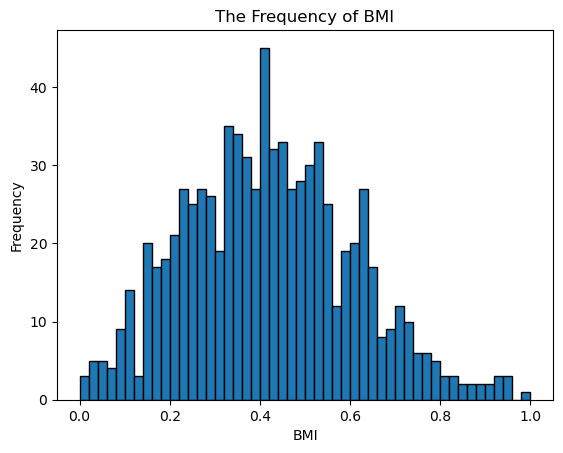

In [148]:
plt.hist(X_train_transformed['bmi'], bins=50, edgecolor='black')

plt.title("The Frequency of BMI")

plt.xlabel("BMI")
plt.ylabel("Frequency")

# Display the output
plt.show()

2) Histogram for cleaned Age

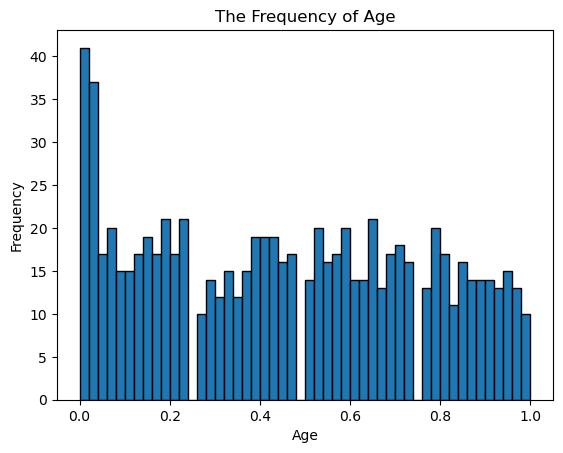

In [151]:
plt.hist(X_train_transformed['age'], bins=50, edgecolor='black')

plt.title("The Frequency of Age")

plt.xlabel("Age")
plt.ylabel("Frequency")

# Display the output
plt.show()

3) Histogram for cleaned Children

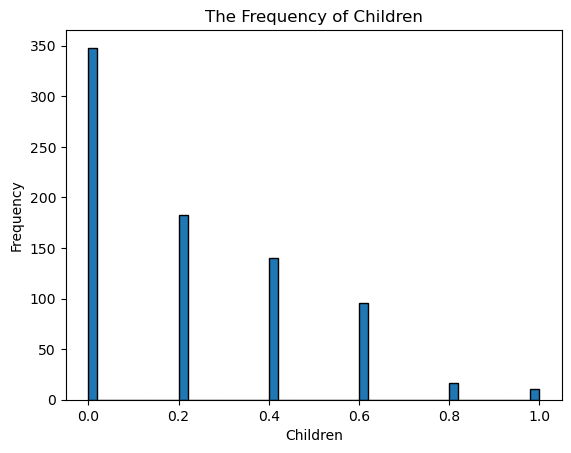

In [154]:
plt.hist(X_train_transformed['children'], bins=50, edgecolor='black')

plt.title("The Frequency of Children")

plt.xlabel("Children")
plt.ylabel("Frequency")

# Display the output
plt.show()

4) Histogram for cleaned Charges

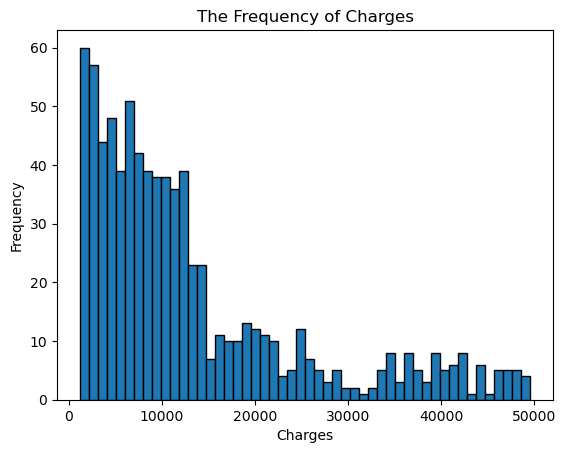

In [157]:
plt.hist(y_train_transformed, bins=50, edgecolor='black')

plt.title("The Frequency of Charges")

plt.xlabel("Charges")
plt.ylabel("Frequency")

# Display the output
plt.show()

2) **Combine the trainig target with the training features together to calculate the correlation between the features and the charges after cleaning.**

In [160]:
# Reset index to ensure they are aligned
X_train_transformed = X_train_transformed.reset_index(drop=True)
y_train_transformed = y_train_transformed.reset_index(drop=True)

# Now combine them
clean_data = pd.concat([X_train_transformed, y_train_transformed], axis=1)


In [162]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 795 entries, 0 to 794
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               795 non-null    object 
 1   bmi               795 non-null    object 
 2   children          795 non-null    object 
 3   sex               795 non-null    int64  
 4   smoker            795 non-null    int64  
 5   region_northeast  795 non-null    float64
 6   region_northwest  795 non-null    float64
 7   region_southeast  795 non-null    float64
 8   region_southwest  795 non-null    float64
 9   charges           795 non-null    float64
dtypes: float64(5), int64(2), object(3)
memory usage: 62.2+ KB


- **Correlation of Training data after cleaning**

In [165]:
clean_data.corr()

,age,bmi,children,sex,smoker,region_northeast,region_northwest,region_southeast,region_southwest,charges
age,1.000000,0.081864,0.069957,0.003478,-0.020418,-0.029322,0.021137,-0.007396,0.015914,0.306596
bmi,0.081864,1.000000,0.005224,0.022565,-0.004136,-0.156367,-0.082242,0.231363,-0.015645,0.169747
children,0.069957,0.005224,1.000000,0.005696,-0.024578,0.025105,0.025914,-0.036708,-0.011102,0.063339
sex,0.003478,0.022565,0.005696,1.000000,0.059505,0.026010,0.016609,-0.016588,-0.024831,0.052241
smoker,-0.020418,-0.004136,-0.024578,0.059505,1.000000,0.029063,-0.071905,0.082998,-0.047496,0.774212
region_northeast,-0.029322,-0.156367,0.025105,0.026010,0.029063,1.000000,-0.305223,-0.361905,-0.287440,0.028252
region_northwest,0.021137,-0.082242,0.025914,0.016609,-0.071905,-0.305223,1.000000,-0.380136,-0.301920,-0.062948
region_southeast,-0.007396,0.231363,-0.036708,-0.016588,0.082998,-0.361905,-0.380136,1.000000,-0.357989,0.085536
region_southwest,0.015914,-0.015645,-0.011102,-0.024831,-0.047496,-0.287440,-0.301920,-0.357989,1.000000,-0.058758
charges,0.306596,0.169747,0.063339,0.052241,0.774212,0.028252,-0.062948,0.085536,-0.058758,1.000000


- **Heat Map of Training data after cleaning**

<Axes: >

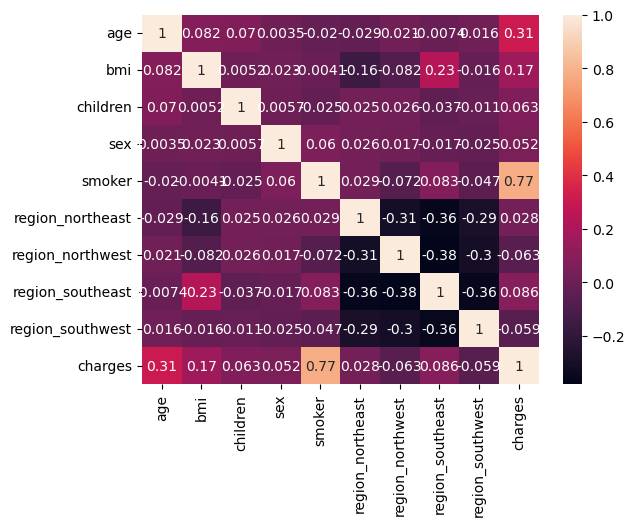

In [168]:
sns.heatmap(clean_data.corr(),annot=True)

**This heat map shows that the correlation between age and charges has increased in the cleaned dataset compared to data before cleaning**

**1- Smoker vs. Charges:**
- Before cleaning: A strong positive correlation (0.78) between smoker and charges exists.
-  After cleaning: This correlation remains strong (0.77), with negligible change.

**2- BMI vs. Charges:**
- Before cleaning: Moderate positive correlation (0.21).
- After cleaning: Slightly reduced correlation (0.17), likely due to changes in how BMI values relate to charges after filtering outliers or inconsistencies.
  
**3-  Age vs. Charges:**
- Before cleaning: Positive correlation (0.13).
- After cleaning: Stronger correlation (0.31), possibly due to removal of data points with irregular relationships between age and charges.
  
**4-  Sex vs. Charges:**
- Minimal correlation with charges in both cases (0.05 before and 0.052 after).
  
**5- Children vs. Charges:**
- Weak positive correlation in both cases (0.05 before vs. 0.063 after), suggesting this variable's influence on charges remains minimal.
  
**6- Region Variables:**

- Negligible correlation with charges in both cases.


## **Step 4: Selecting Machines learning model**

### **Models with Adam Optimizer**

#### First Adam model with 3 layers, epochs=500, no dropout

We will start with adam model that has 3 hidden layers, epochs=500 and no dropout layer

In [179]:
from tensorflow import keras
from tensorflow.keras import layers

# Define the model with adjusted dropout and more units
first_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(9,)),   
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

# Display model summary
first_model.summary()


C:\Users\97154\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

In [181]:
# Compile the model with Adam optimizer
first_model.compile(optimizer='adam', 
                       loss='mean_absolute_error', 
                       metrics=['mean_absolute_error'])

In [183]:
# Fit the model
history1 = first_model.fit(
    X_train_transformed, y_train_transformed,
    epochs=500,
    validation_data=(X_val_transformed, y_val_transformed),
)

Epoch 1/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 12890.6240 - mean_absolute_error: 12890.6240 - val_loss: 12847.1787 - val_mean_absolute_error: 12847.1787
Epoch 2/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12994.3975 - mean_absolute_error: 12994.3975 - val_loss: 12846.1621 - val_mean_absolute_error: 12846.1621
Epoch 3/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13219.2891 - mean_absolute_error: 13219.2891 - val_loss: 12842.0752 - val_mean_absolute_error: 12842.0752
Epoch 4/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12832.1826 - mean_absolute_error: 12832.1826 - val_loss: 12828.0537 - val_mean_absolute_error: 12828.0537
Epoch 5/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12482.8252 - mean_absolute_error: 12482.8252 - val_loss: 12788.5000 - val_mean_absolute_error: 12788.5000
Epoch 6/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13338.5859 - mean_absolute_error: 13338.5859 - val_loss: 12697.8838 - val_mean_absolute_error: 12697.8838
Epoch 7/5

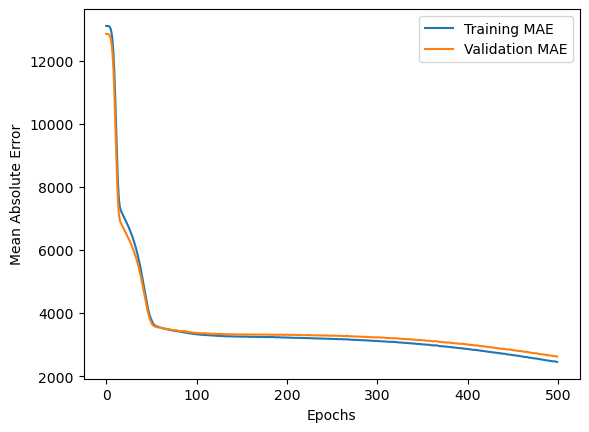

In [185]:
# Plot training and validation MAE
import matplotlib.pyplot as plt

plt.plot(history1.history['mean_absolute_error'], label='Training MAE')
plt.plot(history1.history['val_mean_absolute_error'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

#### Second Adam model with 4 layers, epochs=500,no dropout.


- We increase the number of hidden layers to prevent the model from being underfitting and see if the error will decrease.

In [191]:
from tensorflow import keras
from tensorflow.keras import layers

second_model =  keras.Sequential([
    layers.Dense(128, input_shape=(9,), activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)  # Output layer for regression
])
# Display summary of the model
second_model.summary()

C:\Users\97154\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 0 (0.00 B)

In [193]:
second_model.compile(optimizer='adam', 
                       loss='mean_absolute_error', 
                       metrics=['mae'])

In [195]:
# Fit the model
history2 = second_model.fit(
    X_train_transformed, y_train_transformed,
    epochs=500,
    batch_size=32,
    validation_data=(X_val_transformed, y_val_transformed),
)

Epoch 1/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 13349.9424 - mae: 13349.9424 - val_loss: 12843.6680 - val_mae: 12843.6680
Epoch 2/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12827.1162 - mae: 12827.1162 - val_loss: 12815.0264 - val_mae: 12815.0264
Epoch 3/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12922.9727 - mae: 12922.9727 - val_loss: 12644.5469 - val_mae: 12644.5469
Epoch 4/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13028.2490 - mae: 13028.2490 - val_loss: 11920.2959 - val_mae: 11920.2959
Epoch 5/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11759.2646 - mae: 11759.2646 - val_loss: 9840.9551 - val_mae: 9840.9551
Epoch 6/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9151.4551 - mae: 9151.4551 - val_loss: 7209.4678 - val_mae: 7209.4678
Epoch 7/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7590.8794 - mae: 7590.8794 - val_loss: 6818.8398 - val_mae: 6818.8398
Epoch 8/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7071.4238 - mae: 70

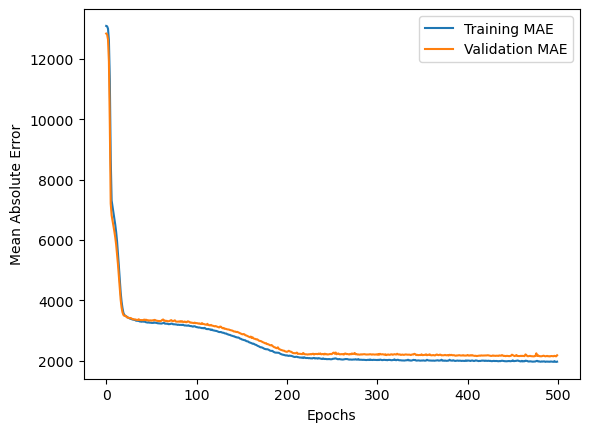

In [197]:
# Plot training and validation MAE
import matplotlib.pyplot as plt

plt.plot(history2.history['mae'], label='Training MAE')
plt.plot(history2.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

#### Third Adam model with 3 layers, epochs=500, with 0.2 dropout.


In [199]:
from tensorflow import keras
from tensorflow.keras import layers

third_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(9,)),
    layers.Dropout(0.2),  # Dropout to reduce overfitting
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)  # Output layer for regression
])

third_model.summary()


C:\Users\97154\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,649 (45.50 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 0 (0.00 B)

In [201]:
third_model.compile(optimizer='adam',
                           loss='mean_absolute_error',
                           metrics=['mae'])

In [203]:
history3= third_model.fit(
    X_train_transformed, y_train_transformed,
    epochs=500,
    batch_size=32,
    validation_data=(X_val_transformed, y_val_transformed),
)


Epoch 1/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 13206.8643 - mae: 13206.8643 - val_loss: 12845.2529 - val_mae: 12845.2529
Epoch 2/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13115.6123 - mae: 13115.6123 - val_loss: 12832.0088 - val_mae: 12832.0088
Epoch 3/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12100.2393 - mae: 12100.2393 - val_loss: 12765.2607 - val_mae: 12765.2607
Epoch 4/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13218.5742 - mae: 13218.5742 - val_loss: 12533.1904 - val_mae: 12533.1904
Epoch 5/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12553.2451 - mae: 12553.2451 - val_loss: 11911.1689 - val_mae: 11911.1689
Epoch 6/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12122.9824 - mae: 12122.9824 - val_loss: 10629.6689 - val_mae: 10629.6689
Epoch 7/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9774.4600 - mae: 9774.4600 - val_loss: 8825.5195 - val_mae: 8825.5195
Epoch 8/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8484.4873 - m

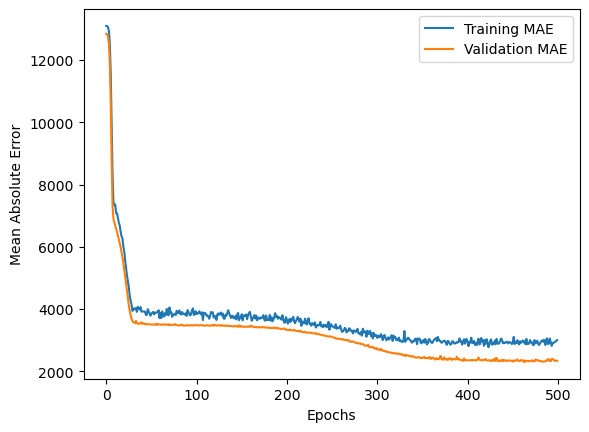

In [205]:
plt.plot(history3.history['mae'], label='Training MAE')
plt.plot(history3.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

### **RMSprop Optimizer models**

#### First RMSprop model, with 3 layers, epochs=500, 0.2 dropout.

In [207]:
from tensorflow import keras
from tensorflow.keras import layers


model_rmsprop1 = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(9,)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
model_rmsprop1.summary()

C:\Users\97154\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,649 (45.50 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 0 (0.00 B)

In [209]:
model_rmsprop1.compile(optimizer='rmsprop',
                loss='mean_squared_error',
                metrics=['mean_absolute_error'])

In [211]:
history_rmsprop1 = model_rmsprop1.fit(X_train_transformed, y_train_transformed, 
                        epochs=500, 
                        validation_data=(X_val_transformed, y_val_transformed))

Epoch 1/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 312944256.0000 - mean_absolute_error: 13174.1953 - val_loss: 295020928.0000 - val_mean_absolute_error: 12838.5996
Epoch 2/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 317120480.0000 - mean_absolute_error: 13199.8564 - val_loss: 294099936.0000 - val_mean_absolute_error: 12806.4414
Epoch 3/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 307597120.0000 - mean_absolute_error: 12921.0361 - val_loss: 291840032.0000 - val_mean_absolute_error: 12727.4707
Epoch 4/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 313859104.0000 - mean_absolute_error: 13251.5312 - val_loss: 287640960.0000 - val_mean_absolute_error: 12579.4492
Epoch 5/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 286374496.0000 - mean_absolute_error: 12516.4307 - val_loss: 280766528.0000 - val_mean_absolute_error: 12333.3252
Epoch 6/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 307476640.0000 - mean_absolute_error: 12893.0195 - val_loss: 271126144.0000

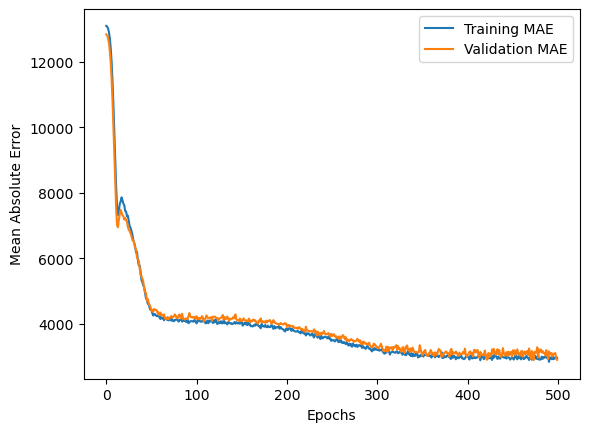

In [213]:
plt.plot(history_rmsprop1.history['mean_absolute_error'], label='Training MAE')
plt.plot(history_rmsprop1.history['val_mean_absolute_error'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

#### Second RMSprop model with 4 layers,epochs=400,no dropout. 

- We will test this model first with 400 epochs and tuned its hyperparameters by increasing the epochs from 400 to 600 to see if it will overfit or the error will decrease.

In [215]:
from tensorflow.keras import layers
from tensorflow import keras

# Define the model with adjusted dropout and more units
model_rmsprop2 = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(9,)), 
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

# Display model summary
model_rmsprop2.summary()


model_rmsprop2.compile(optimizer = 'rmsprop', 
                       loss='mean_absolute_error', 
                       metrics=['mae'])

C:\Users\97154\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 512)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,505 (677.75 KB)

 Trainable params: 173,505 (677.75 KB)

 Non-trainable params: 0 (0.00 B)

In [217]:
# Fit the model
history_rmsprop2 = model_rmsprop2.fit(
    X_train_transformed, y_train_transformed,
    epochs=400,
    batch_size=32,
    validation_data=(X_val_transformed, y_val_transformed),
)

Epoch 1/400
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 12993.7637 - mae: 12993.7637 - val_loss: 12106.0430 - val_mae: 12106.0430
Epoch 2/400
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11056.8740 - mae: 11056.8740 - val_loss: 8076.1543 - val_mae: 8076.1543
Epoch 3/400
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7901.2114 - mae: 7901.2114 - val_loss: 6805.2046 - val_mae: 6805.2046
Epoch 4/400
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7120.8745 - mae: 7120.8745 - val_loss: 6503.0654 - val_mae: 6503.0654
Epoch 5/400
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6375.4673 - mae: 6375.4673 - val_loss: 6175.0977 - val_mae: 6175.0977
Epoch 6/400
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6083.9404 - mae: 6083.9404 - val_loss: 5508.3271 - val_mae: 5508.3271
Epoch 7/400
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5339.1577 - mae: 5339.1577 - val_loss: 4842.9697 - val_mae: 4842.9697
Epoch 8/400
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4387.9595 - mae: 4387.9595 - va

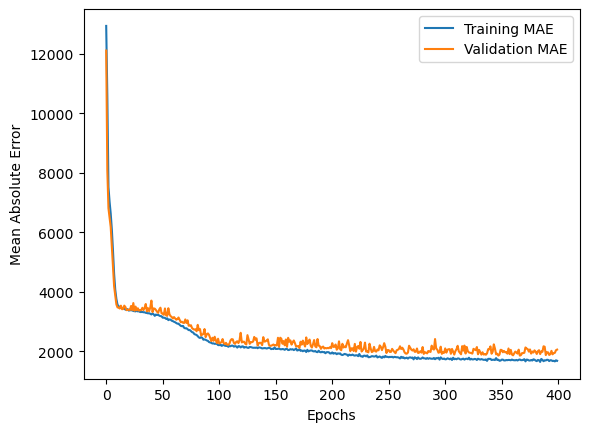

In [219]:
# Plot training and validation MAE
import matplotlib.pyplot as plt

plt.plot(history_rmsprop2.history['mae'], label='Training MAE')
plt.plot(history_rmsprop2.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()


- The error is still decreasing, so will increase the number of epochs to 600.

#### Second RMSprop model with 4 layers,epochs=600,no dropout. 

- Now, we will train the model with 600 epochs.

In [177]:
from tensorflow.keras import layers
from tensorflow import keras

# Define the model with adjusted dropout and more units
model_rmsprop2_600 = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(9,)), 
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

# Display model summary
model_rmsprop2_600.summary()


model_rmsprop2_600.compile(optimizer = 'rmsprop', 
                       loss='mean_absolute_error', 
                       metrics=['mae'])

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,505 (677.75 KB)

 Trainable params: 173,505 (677.75 KB)

 Non-trainable params: 0 (0.00 B)

In [179]:
# Fit the model but with 600 epochs this time
history_rmsprop2_600 = model_rmsprop2_600.fit(
    X_train_transformed, y_train_transformed,
    epochs=600,
    batch_size=32,
    validation_data=(X_val_transformed, y_val_transformed),
)

Epoch 1/600
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 13409.2744 - mae: 13409.2744 - val_loss: 12135.0566 - val_mae: 12135.0566
Epoch 2/600
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12315.7236 - mae: 12315.7236 - val_loss: 8198.2090 - val_mae: 8198.2090
Epoch 3/600
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7339.8354 - mae: 7339.8354 - val_loss: 6740.3872 - val_mae: 6740.3872
Epoch 4/600
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7997.9331 - mae: 7997.9331 - val_loss: 6421.2710 - val_mae: 6421.2710
Epoch 5/600
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6676.0894 - mae: 6676.0894 - val_loss: 5994.9805 - val_mae: 5994.9805
Epoch 6/600
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6026.1372 - mae: 6026.1372 - val_loss: 5391.4658 - val_mae: 5391.4658
Epoch 7/600
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5427.8623 - mae: 5427.8623 - val_loss: 4788.4365 - val_mae: 4788.4365
Epoch 8/600
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4849.4766 - mae: 4849.4766 - val

In [175]:
# Plot training and validation MAE
import matplotlib.pyplot as plt

plt.plot(history_rmsprop2_600 .history['mae'], label='Training MAE')
plt.plot(history_rmsprop2_600 .history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

NameError: name 'history_rmsprop2_600' is not defined

- Based on this graph, as we increase the number of epochs to 600, both the training MAE and validation MAE continues to decrease.
- at 600 epochs the validation MAE stabilizes.

#### Third RMSprop model with 5 layers,epochs=500,no dropout. 

- We will increase the number of layers to see if the error will decrease futher or it will overfit the model.

In [227]:
from tensorflow.keras import layers
from tensorflow import keras

model_rmsprop3 = keras.Sequential([
    
    layers.Dense(256, activation='relu', input_shape=(9,)),  
    layers.Dense(124, activation='relu'),                   
    layers.Dense(64, activation='relu'),                    
    layers.Dense(32, activation='relu'),                    
    layers.Dense(16, activation='relu'),                    
    layers.Dense(1)                                       
])

model_rmsprop3.summary()


model_rmsprop3.compile(
    optimizer='rmsprop',            
    loss='mean_absolute_error',       
    metrics=['mae']                    
)

C:\Users\97154\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 256)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 124)            │        31,868 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,053 (175.99 KB)

 Trainable params: 45,053 (175.99 KB)

 Non-trainable params: 0 (0.00 B)

In [229]:
history_rmsprop3 = model_rmsprop3.fit(
    X_train_transformed, y_train_transformed, 
    epochs=500, 
    validation_data=(X_val_transformed, y_val_transformed)
)

Epoch 1/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 13326.8516 - mae: 13326.8516 - val_loss: 12738.7646 - val_mae: 12738.7646
Epoch 2/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12681.7275 - mae: 12681.7275 - val_loss: 11531.7588 - val_mae: 11531.7588
Epoch 3/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11195.1436 - mae: 11195.1436 - val_loss: 8238.1260 - val_mae: 8238.1260
Epoch 4/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7424.0693 - mae: 7424.0693 - val_loss: 6875.1055 - val_mae: 6875.1055
Epoch 5/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6742.7432 - mae: 6742.7432 - val_loss: 6644.1924 - val_mae: 6644.1924
Epoch 6/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7857.6914 - mae: 7857.6914 - val_loss: 6430.6602 - val_mae: 6430.6602
Epoch 7/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7044.2881 - mae: 7044.2881 - val_loss: 6062.4893 - val_mae: 6062.4893
Epoch 8/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6424.7314 - mae: 6424.7314 

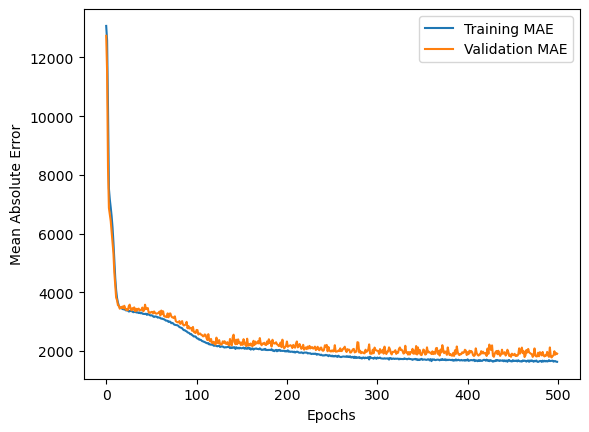

In [231]:
import matplotlib.pyplot as plt

plt.plot(history_rmsprop3.history['mae'], label='Training MAE')
plt.plot(history_rmsprop3.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

- Although the MAE was similar to the model with 4 layers, we decided to go with the 4-layer model because it reduces the risk of overfitting, is simpler, and requires less computational power. This choice ensures we minimize the risk of overfitting on unseen data.

#### Fourth RMSprop model with 5 layers,epochs=500,0.1 dropout. 

In [233]:
from tensorflow.keras import layers
from tensorflow import keras

model_rmsprop4 = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(9,)), 
    layers.Dropout(0.1),                                    
    layers.Dense(128, activation='relu'),                   
    layers.Dropout(0.1),                                                                    
    layers.Dense(64, activation='relu'),                   
    layers.Dense(32, activation='relu'),                    
    layers.Dense(16, activation='relu'),                                    
    layers.Dense(1)                                         
])


model_rmsprop4.summary()


model_rmsprop4.compile(
    optimizer='rmsprop',               
    loss='mean_absolute_error',        
    metrics=['mae']                    
)

C:\Users\97154\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_41 (Dense)                │ (None, 256)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,337 (181.00 KB)

 Trainable params: 46,337 (181.00 KB)

 Non-trainable params: 0 (0.00 B)

In [235]:
history_rmsprop4 = model_rmsprop4.fit(
    X_train_transformed, y_train_transformed, 
    epochs=500, 
    validation_data=(X_val_transformed, y_val_transformed)
)

Epoch 1/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 13015.8301 - mae: 13015.8301 - val_loss: 12788.8672 - val_mae: 12788.8672
Epoch 2/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12457.6533 - mae: 12457.6533 - val_loss: 12085.3633 - val_mae: 12085.3633
Epoch 3/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11812.5586 - mae: 11812.5586 - val_loss: 9509.6279 - val_mae: 9509.6279
Epoch 4/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9804.9141 - mae: 9804.9141 - val_loss: 7105.9136 - val_mae: 7105.9136
Epoch 5/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7840.7188 - mae: 7840.7188 - val_loss: 6748.1465 - val_mae: 6748.1465
Epoch 6/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7170.8096 - mae: 7170.8096 - val_loss: 6558.3179 - val_mae: 6558.3179
Epoch 7/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7026.4941 - mae: 7026.4941 - val_loss: 6338.4541 - val_mae: 6338.4541
Epoch 8/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6690.7153 - mae: 6690.7153 

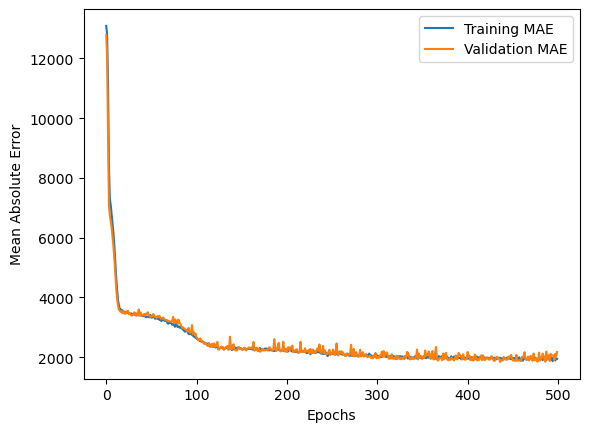

In [237]:
plt.plot(history_rmsprop4.history['mae'], label='Training MAE')
plt.plot(history_rmsprop4.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

### **Step 5: Cross-Validation**

- We will apply cross validation to the last 4 models, to choose which model is the best

#### **model_rmsprop2**

In [241]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# Initialize KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Prepare to store results
fold = 1
mse_scores = []
mae_scores = []

for train_idx, val_idx in kf.split(X_train_transformed):
    print(f"Training Fold {fold}...")
    
    # Split the training data into new training and validation sets
    X_train_fold, X_val_fold = X_train_transformed.iloc[train_idx], X_train_transformed.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_transformed.iloc[train_idx], y_train_transformed.iloc[val_idx]

    
    # Train the model
    model_rmsprop2.fit(X_train_fold, y_train_fold, epochs=400, verbose=0)
    
    # Evaluate on the validation fold
    y_val_pred = model_rmsprop2.predict(X_val_fold).flatten()
    mse = mean_squared_error(y_val_fold, y_val_pred)
    mae = np.mean(np.abs(y_val_fold - y_val_pred))
    
    print(f"Fold {fold} - MSE: {mse:.4f}, MAE: {mae:.4f}")
    
    mse_scores.append(mse)
    mae_scores.append(mae)
    fold += 1

# Print average performance across folds
print(f"\nAverage MSE: {np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}")
print(f"Average MAE: {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")

Training Fold 1...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Fold 1 - MSE: 26255711.3596, MAE: 2092.0995
Training Fold 2...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  
Fold 2 - MSE: 18412779.6418, MAE: 1489.8007
Training Fold 3...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 3 - MSE: 21787937.4063, MAE: 1894.8171
Training Fold 4...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Fold 4 - MSE: 33928630.0806, MAE: 2107.2602
Training Fold 5...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Fold 5 - MSE: 23079217.3896, MAE: 2101.7076

Average MSE: 24692855.1756 ± 5257828.0765
Average MAE: 1937.1370 ± 237.4614


#### **model_rmsprop2_600**

In [243]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# Initialize KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Prepare to store results
fold = 1
mse_scores = []
mae_scores = []

for train_idx, val_idx in kf.split(X_train_transformed):
    print(f"Training Fold {fold}...")
    
    # Split the training data into new training and validation sets
    X_train_fold, X_val_fold = X_train_transformed.iloc[train_idx], X_train_transformed.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_transformed.iloc[train_idx], y_train_transformed.iloc[val_idx]

    
    # Train the model
    model_rmsprop2_600.fit(X_train_fold, y_train_fold, epochs=400, verbose=0)
    
    # Evaluate on the validation fold
    y_val_pred = model_rmsprop2_600.predict(X_val_fold).flatten()
    mse = mean_squared_error(y_val_fold, y_val_pred)
    mae = np.mean(np.abs(y_val_fold - y_val_pred))
    
    print(f"Fold {fold} - MSE: {mse:.4f}, MAE: {mae:.4f}")
    
    mse_scores.append(mse)
    mae_scores.append(mae)
    fold += 1

# Print average performance across folds
print(f"\nAverage MSE: {np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}")
print(f"Average MAE: {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")

Training Fold 1...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Fold 1 - MSE: 25779416.1434, MAE: 2030.3308
Training Fold 2...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Fold 2 - MSE: 18236411.6929, MAE: 1599.8178
Training Fold 3...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Fold 3 - MSE: 21403043.3728, MAE: 1895.3333
Training Fold 4...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Fold 4 - MSE: 34062694.0590, MAE: 1867.9687
Training Fold 5...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Fold 5 - MSE: 27195724.3487, MAE: 2040.7073

Average MSE: 25335457.9234 ± 5397827.0113
Average MAE: 1886.8316 ± 159.4207


#### **model_rmsprop3**

In [245]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# Initialize KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Prepare to store results
fold = 1
mse_scores = []
mae_scores = []

for train_idx, val_idx in kf.split(X_train_transformed):
    print(f"Training Fold {fold}...")
    
    # Split the training data into new training and validation sets
    X_train_fold, X_val_fold = X_train_transformed.iloc[train_idx], X_train_transformed.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_transformed.iloc[train_idx], y_train_transformed.iloc[val_idx]

    
    # Train the model
    model_rmsprop3.fit(X_train_fold, y_train_fold, epochs=400, verbose=0)
    
    # Evaluate on the validation fold
    y_val_pred = model_rmsprop3.predict(X_val_fold).flatten()
    mse = mean_squared_error(y_val_fold, y_val_pred)
    mae = np.mean(np.abs(y_val_fold - y_val_pred))
    
    print(f"Fold {fold} - MSE: {mse:.4f}, MAE: {mae:.4f}")
    
    mse_scores.append(mse)
    mae_scores.append(mae)
    fold += 1

# Print average performance across folds
print(f"\nAverage MSE: {np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}")
print(f"Average MAE: {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")

Training Fold 1...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Fold 1 - MSE: 25594661.0957, MAE: 2036.4738
Training Fold 2...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step
Fold 2 - MSE: 17506438.6540, MAE: 1507.7787
Training Fold 3...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Fold 3 - MSE: 21967508.5626, MAE: 1825.6573
Training Fold 4...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 4 - MSE: 35012181.8804, MAE: 1943.9005
Training Fold 5...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Fold 5 - MSE: 25665154.6661, MAE: 2006.4457

Average MSE: 25149188.9718 ± 5766767.1667
Average MAE: 1864.0512 ± 192.2425


#### **model_rmsprop4**

In [247]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# Initialize KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Prepare to store results
fold = 1
mse_scores = []
mae_scores = []

for train_idx, val_idx in kf.split(X_train_transformed):
    print(f"Training Fold {fold}...")
    
    # Split the training data into new training and validation sets
    X_train_fold, X_val_fold = X_train_transformed.iloc[train_idx], X_train_transformed.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_transformed.iloc[train_idx], y_train_transformed.iloc[val_idx]

    
    # Train the model
    model_rmsprop4.fit(X_train_fold, y_train_fold, epochs=400, verbose=0)
    
    # Evaluate on the validation fold
    y_val_pred = model_rmsprop4.predict(X_val_fold).flatten()
    mse = mean_squared_error(y_val_fold, y_val_pred)
    mae = np.mean(np.abs(y_val_fold - y_val_pred))
    
    print(f"Fold {fold} - MSE: {mse:.4f}, MAE: {mae:.4f}")
    
    mse_scores.append(mse)
    mae_scores.append(mae)
    fold += 1

# Print average performance across folds
print(f"\nAverage MSE: {np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}")
print(f"Average MAE: {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")

Training Fold 1...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Fold 1 - MSE: 26363650.9851, MAE: 2103.8580
Training Fold 2...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 2 - MSE: 15143490.2467, MAE: 1243.6639
Training Fold 3...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Fold 3 - MSE: 21345215.7076, MAE: 1745.2876
Training Fold 4...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Fold 4 - MSE: 34931770.5169, MAE: 1795.3561
Training Fold 5...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Fold 5 - MSE: 29797928.1798, MAE: 2130.9162

Average MSE: 25516411.1272 ± 6821943.3435
Average MAE: 1803.8164 ± 320.7140


### Save the best model.

- Accoarding to the graph and the cross validation model_rmsprop2_600 is the best model.

In [283]:
model_rmsprop2_600.save('trained_model.keras')